<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/Caso_de_regresi%C3%B3n_logar%C3%ADtmica_con_datos_de_inversi%C3%B3n_y_ventas_de_servicios_funerarios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto

Se utilizan el mismo conjunto de datos que se describió para el caso de estudio de regresión polinomial de R, estos datos se relacionan con el comportamiento de las ventas en razón de la inversión en publicidad de una empresa de servicios funerarios.

Los datos se encuentran en el enlace: https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/datos_inversiones_servicios_funerarios.csv

El sisguiente enlace permite la recreación completa del caso: https://colab.research.google.com/drive/1bMdYJ5H060YgErVEb4_38e3RcMcNUUXM?usp=sharing

El caso también se encuentra para su descarga y verificación en el enlace del poprtal de *github.com* en el espacio del autor.https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/Caso_de_regresi%C3%B3n_logar%C3%ADtmica_con_datos_de_inversi%C3%B3n_y_ventas_de_servicios_funerarios.ipynb





# Objetivo

Implementar, evaluar y comparar rendimiento y calidad predictiva del modelo de regresión logarítmica con datos de inversión y ventas de servicios funerarios.


# Descripción

## Cargar librerías



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import scipy.stats as stats

from statsmodels.stats.stattools import durbin_watson

from sklearn.model_selection import train_test_split # Partir datos
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf # Para modelo logarítmico

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.pipeline import Pipeline
from statsmodels.nonparametric.smoothers_lowess import lowess


## Cargar funciones

Las funciones están disponibles para su descarga en la dirección url de *github.com*: https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/funciones_MLog.py


In [3]:
# Aqui se carga
import requests

url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/funciones_MLog.py"

exec(requests.get(url).text)

## Cargar datos

In [4]:
datos = f_cargar_datos("https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/datos_inversiones_servicios_funerarios.csv")

## Visulizar datos


In [5]:
f_visualizar_head_tail_reducido_word(datos)

,Unnamed: 0,inversion,ventas
0,1,1,195.516194827582
1,2,2,232.815939112131
2,3,3,267.400280946598
3,4,4,269.878785187391
4,5,5,281.506197502993
5,6,6,303.308493356469
6,7,7,300.982837100679
7,8,8,293.85158720714
8,9,9,304.366406051663
9,10,10,311.563958888903


## Descripción estadística


In [6]:
f_describir_datos(datos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   inversion   100 non-null    int64  
 2   ventas      100 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 2.5 KB


{'describe':        Unnamed: 0   inversion      ventas
 count  100.000000  100.000000  100.000000
 mean    50.500000   50.500000  382.592935
 std     29.011492   29.011492   47.236216
 min      1.000000    1.000000  195.516195
 25%     25.750000   25.750000  355.225498
 50%     50.500000   50.500000  397.752722
 75%     75.250000   75.250000  417.980113
 max    100.000000  100.000000  446.234213,
 'structure': None}

# Desarrollo

## Partición de los datos

* 70% datos de entranamiento
* 30% datos de validación

Se ejecuta la función  *f_particionar_datos()* y se observan los primeros y últimos registros de los conjuntos de datos de entrenamiento y datos de validación.

In [7]:
# Particionar datos
particion = f_particionar_datos(datos)

datos_entrenamiento = particion["datos_entrenamiento"]
datos_validacion = particion["datos_validacion"]

f_visualizar_head_tail_reducido_word(datos_entrenamiento)


,Unnamed: 0,inversion,ventas
0,1,1,195.516194827582
46,47,47,389.28430140311
61,62,62,402.33813162738
80,81,81,419.768571220821
65,66,66,411.910966232555
39,40,40,381.400204697598
70,71,71,409.205744523613
87,88,88,427.348292650581
89,90,90,434.180944464122
91,92,92,430.476604528517


Datos de validación


In [8]:
f_visualizar_head_tail_reducido_word(datos_validacion)

,Unnamed: 0,inversion,ventas
98,99,99,427.870389633926
10,11,11,329.687418019434
4,5,5,281.506197502993
18,19,19,352.832796170832
88,89,89,421.824365802357
13,14,14,332.838328208324
8,9,9,304.366406051663
84,85,85,420.368670329966
79,80,80,417.990200834182
21,22,22,352.808323350649


## Modelo de regresión logarítmica


In [9]:
modelo_log = f_construir_modelo_log(datos, "inversion", "ventas")

print(modelo_log.summary())

                            OLS Regression Results                            
Dep. Variable:                 ventas   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     4008.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           2.65e-81
Time:                        16:06:02   Log-Likelihood:                -340.15
No. Observations:                 100   AIC:                             684.3
Df Residuals:                      98   BIC:                             689.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           199.6790      2.98

## Modelos polinomiales de primer, segundo y quinto orden


In [10]:
# modelo lineal primer orden
modelo_RP1 = f_construir_modelo(datos_entrenamiento, "inversion", "ventas", grado=1)

# modelo lineal segundo orden
modelo_RP2 = f_construir_modelo(datos_entrenamiento, "inversion", "ventas", grado=2)

# modelo lineal quinto orden
modelo_RP5 = f_construir_modelo(datos_entrenamiento, "inversion", "ventas", grado=5)


## Postulados de los modelos

### Linealidad

En la **FIGURA**, se presentan las tendencias de predicción de cada uno de los modelos de regresión construidos; se observa que el modelo de regresión logarítmica arriba a la izquierda presenta un mejor ajuste de tendencia para estos datos, además el estadístico *r square* es mayor en el modelo regresión logarítmica que en los polinomiales.

Todos los modelos visualizan una linealidad aceptable, sin embaego, el modelo de regresión logaritmica y el polinomial de quinto orden presentan mejor ajuste. Se puede concluir que todos los modelos de regresión para estos datos, cumplen con el postulado de linealidad.


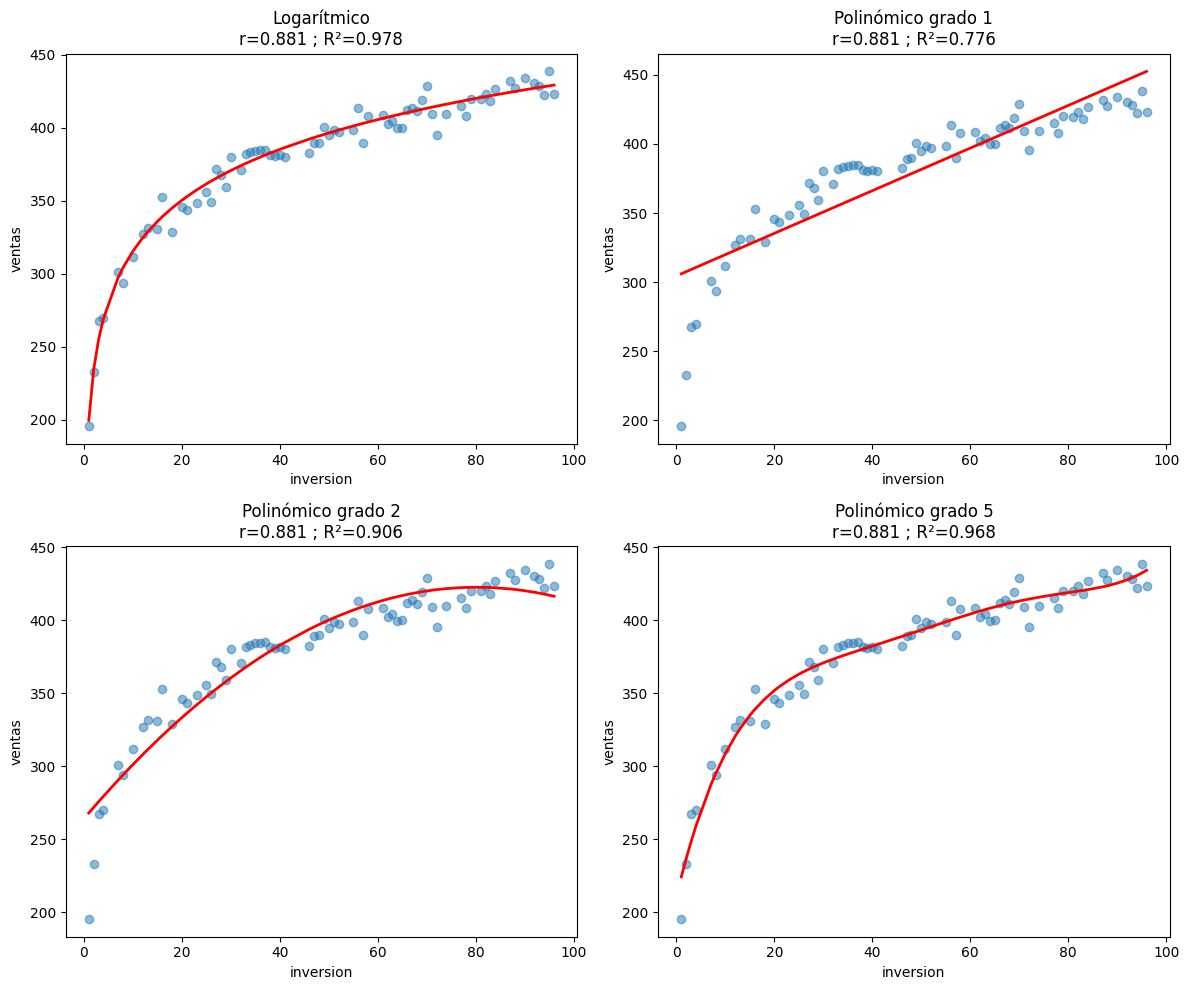

In [11]:
modelos = [modelo_log, modelo_RP1, modelo_RP2, modelo_RP5]

titulos = [
    "Logarítmico",
    "Polinómico grado 1",
    "Polinómico grado 2",
    "Polinómico grado 5"
]

f_diagrama_dispersion_matriz(
    modelos,
    datos_entrenamiento,
    "inversion",
    "ventas",
    titulos
)





### Homocedasticidad

Con respecto al postulado de homocedasticidad se tienen lo siguiente ver **FIGURA**:

El modelo de regresión logarítmica presenta una dispersión relativamente constante; no hay forma clara de embudo y los residuos están distribuidos alrededor de 0, por lo que cumple razonablemente la homocedasticidad.






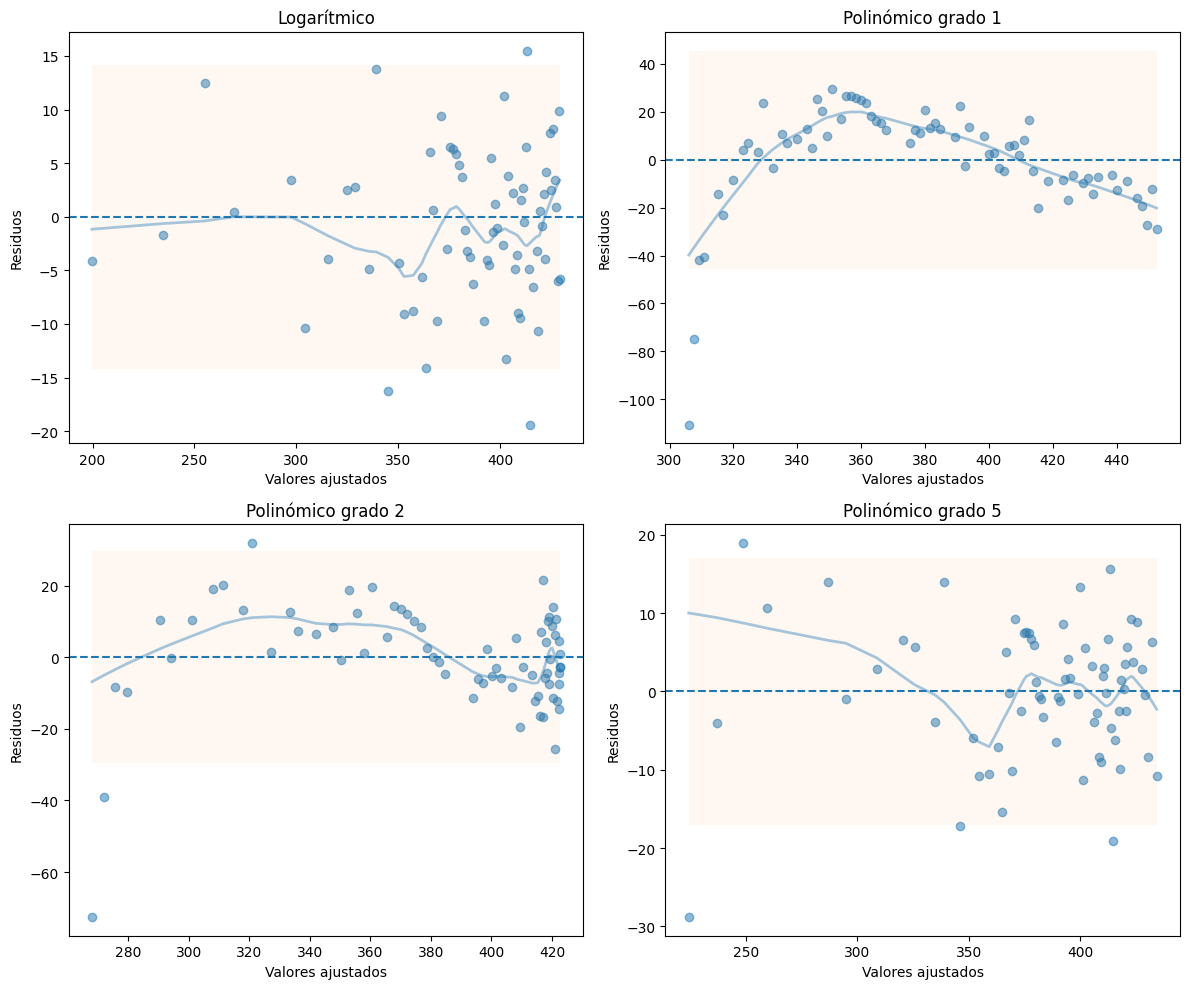

In [12]:
modelos = [modelo_log, modelo_RP1, modelo_RP2, modelo_RP5]

titulos = [
    "Logarítmico",
    "Polinómico grado 1",
    "Polinómico grado 2",
    "Polinómico grado 5"
]

f_matriz_verificar_homocedasticidad(
    modelos,
    datos_entrenamiento,
    "inversion",
    "ventas",
    titulos
)

### Normalidad

Se obser va en **FIGURA** de acuerdo a la valoración del postulado de normalidad de resudios, el modelo de regresión logarítmico y polinomial de quinto orden presentan la característica de que los residuales si tienen un comportamiento de distribución normal.

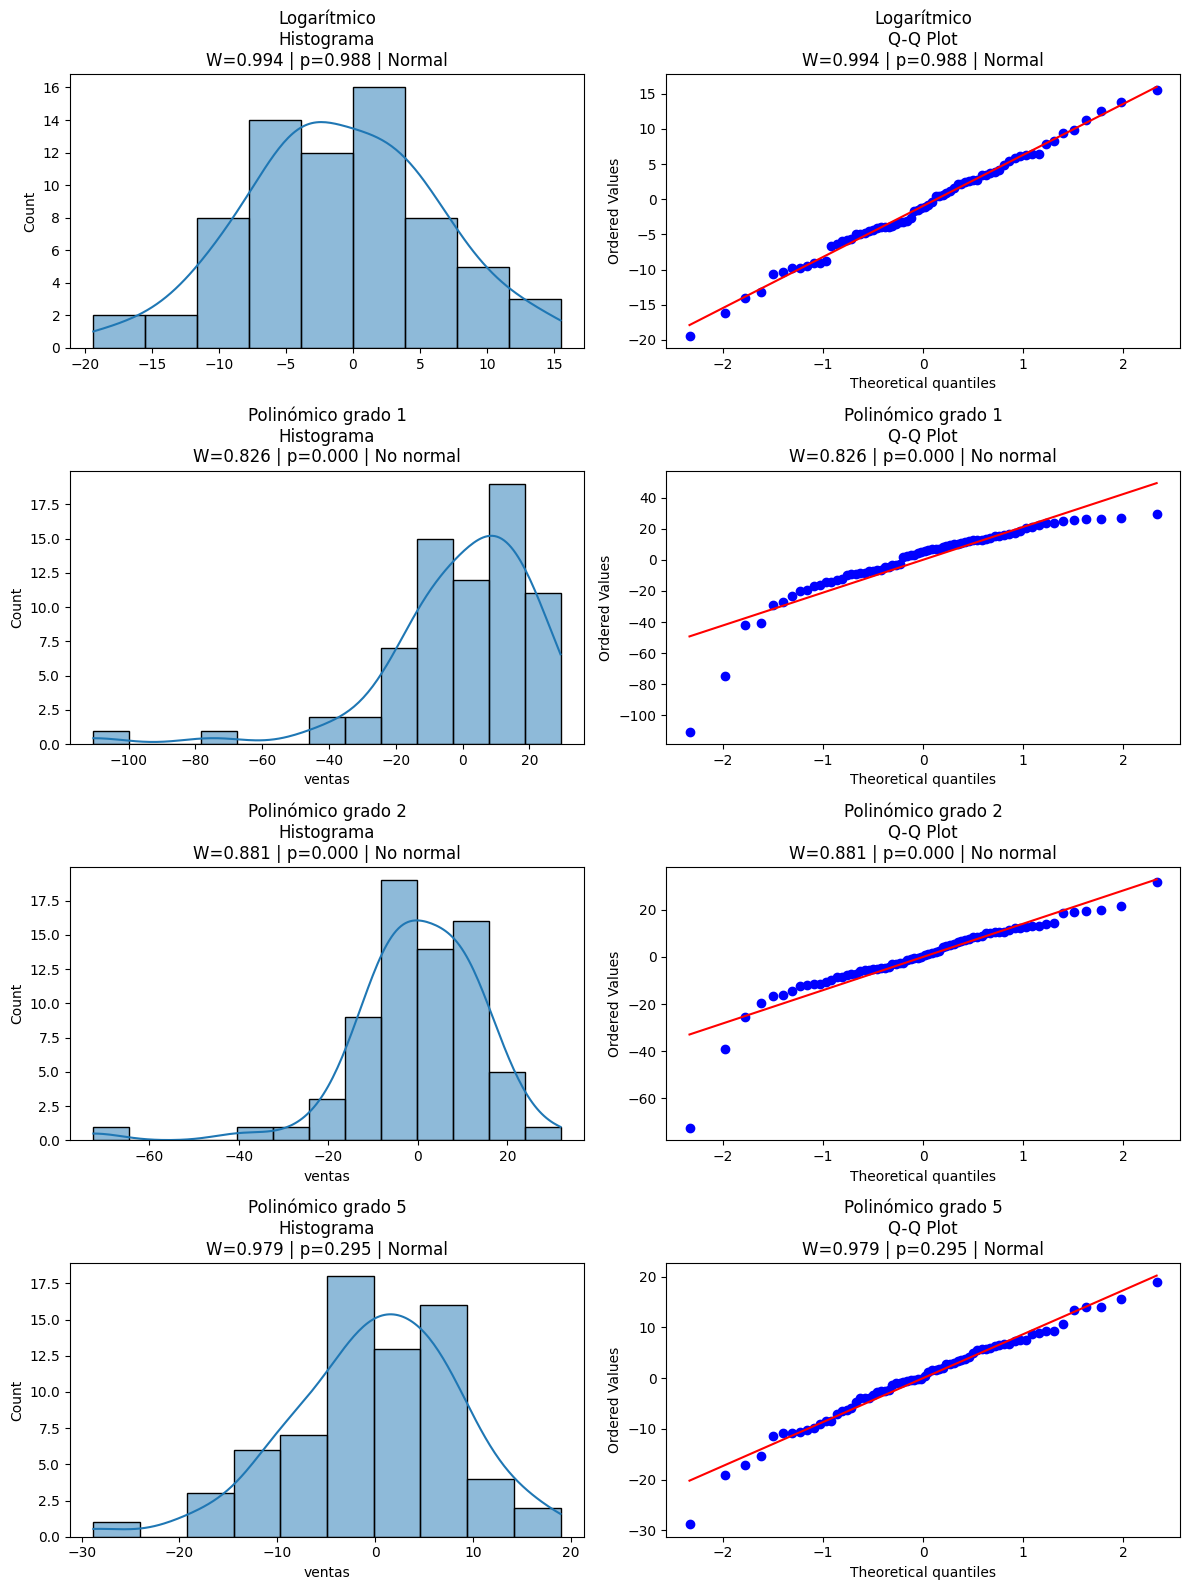

               Modelo         W       p_value Normalidad  Ranking
0         Logarítmico  0.994281  9.884064e-01     Normal      1.0
3  Polinómico grado 5  0.979193  2.952605e-01     Normal      2.0
2  Polinómico grado 2  0.880593  7.201302e-06  No normal      3.0
1  Polinómico grado 1  0.826463  1.298110e-07  No normal      4.0


In [13]:
modelos = [modelo_log, modelo_RP1, modelo_RP2, modelo_RP5]

titulos = [
    "Logarítmico",
    "Polinómico grado 1",
    "Polinómico grado 2",
    "Polinómico grado 5"
]

ranking = f_matriz_normalidad_modelos(
    modelos,
    datos_entrenamiento,
    "inversion",
    "ventas",
    titulos
)

print(ranking)

### Independencia de residuos

Con respecto al postulado de independencia de residuos, los modelos que cumplen con este postulado son el de regresión logarítmica y el polinomial de quinto orden.

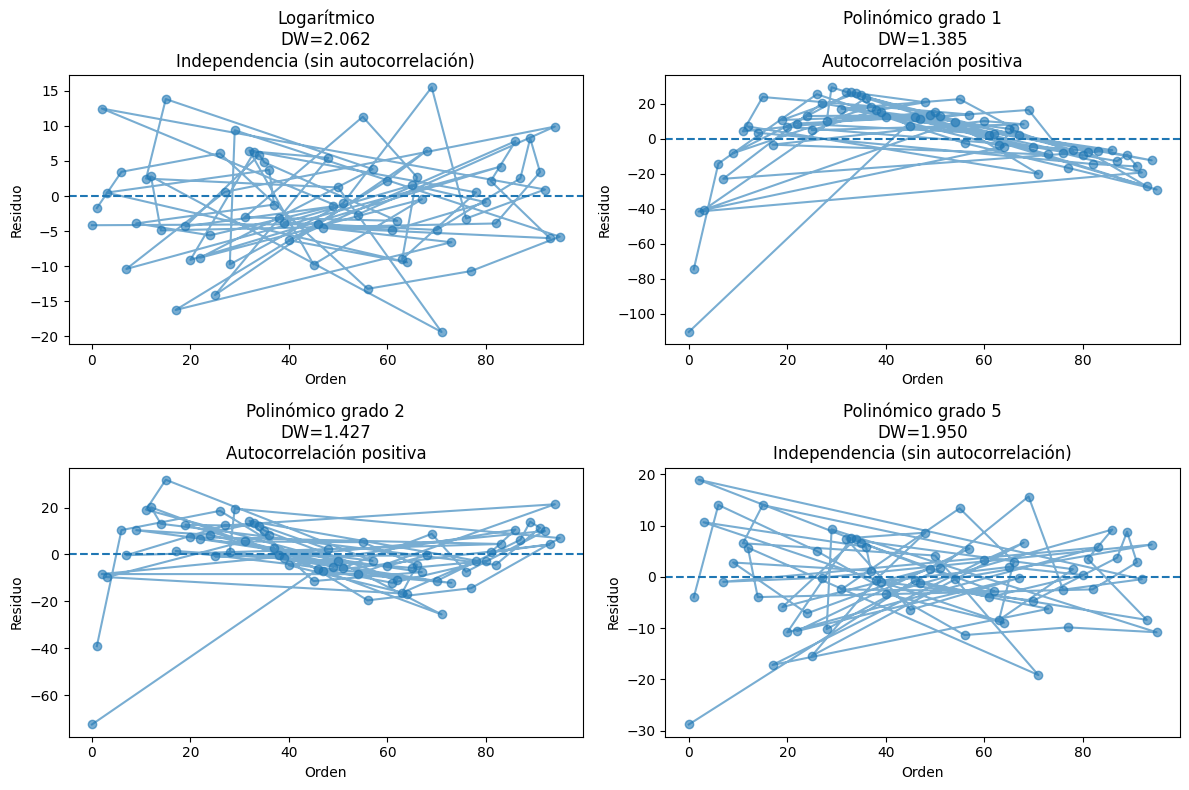

               Modelo  Durbin_Watson                       Interpretacion  \
3  Polinómico grado 5       1.949577  Independencia (sin autocorrelación)   
0         Logarítmico       2.061575  Independencia (sin autocorrelación)   
2  Polinómico grado 2       1.426679             Autocorrelación positiva   
1  Polinómico grado 1       1.384888             Autocorrelación positiva   

   Distancia_2  Ranking  
3     0.050423      1.0  
0     0.061575      2.0  
2     0.573321      3.0  
1     0.615112      4.0  


In [14]:
modelos = [modelo_log, modelo_RP1, modelo_RP2, modelo_RP5]

titulos = [
    "Logarítmico",
    "Polinómico grado 1",
    "Polinómico grado 2",
    "Polinómico grado 5"
]

ranking = f_verificar_independencia_residuos(
    modelos,
    datos_entrenamiento,
    "inversion",
    "ventas",
    titulos
)

print(ranking)

## Coeficientes de los modelos

Con la función *f_ecuaciones_modelos()* se construyen las ecuacioens de cualquier modelo de lineal recta, polonimial y tambieén incluye la construcción de modelos logarítmicos.

Se ejecuta esta función y se exgtraen a partir del modelo, los coeficientes que sirven para construir las ecuaciones que definen las predicciones de los modelos de regresión.




In [15]:
modelos = [modelo_log, modelo_RP1, modelo_RP2, modelo_RP5]

titulos = [
    "Logarítmico",
    "Polinómico grado 1",
    "Polinómico grado 2",
    "Polinómico grado 5"
]

resultado = f_ecuaciones_modelos(
    modelos,
    titulos
)


 Logarítmico

Coeficientes del modelo:
Intercepto: 199.679
np.log(inversion): 50.2871

Ecuación del modelo:
ŷ = 199.679 + 50.2871·ln(inversion)

 Polinómico grado 1

Coeficientes del modelo:
Intercepto: 304.4883
inversion: 1.5422

Ecuación del modelo:
ŷ = 304.4883 + 1.5422·inversion

 Polinómico grado 2

Coeficientes del modelo:
Intercepto: 264.1283
inversion: 3.9527
inversion^2: -0.0246

Ecuación del modelo:
ŷ = 264.1283 + 3.9527·inversion - 0.0246·inversion^2

 Polinómico grado 5

Coeficientes del modelo:
Intercepto: 210.8456
inversion: 13.9631
inversion^2: -0.5047
inversion^3: 0.0096
inversion^4: -0.0001
inversion^5: 0.0

Ecuación del modelo:
ŷ = 210.8456 + 13.9631·inversion - 0.5047·inversion^2 + 0.0096·inversion^3 - 0.0001·inversion^4 + 0.0·inversion^5


<string>:251: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


## Evaluación de los modelos

De acuerdo a la evaluación, el modelo de regresión logarítmica queda en primer lugar con un valor menor en los estadísiticos de *RMSE* y *r square* lo que indica que las predicciones para estos datos son mejores usando este modelo en comparación con los otros aquí valorados; el modelo polinomial de quinto orde serái una interesenta alternativa como modelo predictivo.


In [16]:
modelos = [modelo_log, modelo_RP1, modelo_RP2, modelo_RP5]

titulos = [
    "Logarítmico",
    "Polinómico grado 1",
    "Polinómico grado 2",
    "Polinómico grado 5"
]

resultado = f_evaluar_modelos_varios(
    modelos,
    datos_entrenamiento,
    "ventas",
    "inversion",
    titulos
)

resultado

,R_square,R_square_ajustado,MSE,RMSE,Parametros (p),Modelo
0,0.9779,0.9776,51.0992,7.1484,1,Logarítmico
3,0.9684,0.9660,72.9130,8.5389,5,Polinómico grado 5
2,0.9056,0.9028,217.9631,14.7636,2,Polinómico grado 2
1,0.7757,0.7724,518.0703,22.7612,1,Polinómico grado 1


# Interpretación del caso

El caso de estudio implementó y evaluó un modelo de regresión logarítimica para datos de inversión en publicidad y la relación que tienen estos con las ventas de una empresa de servicios funerarios.

Los resultados que arroja el caso de estudio elaboracion con librerías y funciones de Python, arroja resultados similares que los que se describen con programación R.

Todos los modelos cumplen con el postulado de linealidad; solo el modelo logarítmico cumple con el postulado de homocedasticidad y de manera no tan clara el polinómico de quinto orden; con respecto al postulado de normalidad de residuos e independencia de estos, solo los modelos de regresión logartimica y polinómico de quinto orden cumplen con estos criterios y postulados.

En términos de calidad predicitva el mejor modelo para estos datos es el modelo de regresión logarítmica.

La pregunta es: ¿cuál modelo implementar en producción?, depende del analista o científico de datos, hay que valorar los estadísticos que miden la calidad de predictiva, el cumplimiento de los postulados y tomar decisiones, pero siempre es recomendable tener más de un modelo.

Otra pregunta ¿cuál lenguaje utilziar?, como respuesta es ue las herramientas están para usarse y la decisión es usar el lenguaje que mejor se le acomode al lector, sin embaego siempre es bueno tener alterntivas y puntos  de vista a comparar.


